In [4]:
# !pip install pandas matplotlib seaborn scikit-learn

In [35]:
# ! pip install koreanize-matplotlib

In [3]:
# !pip install notebook==6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

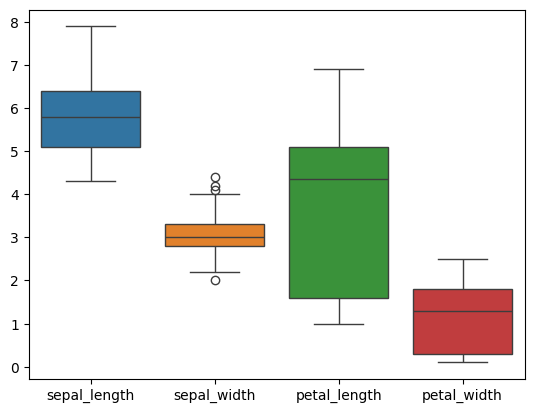

In [9]:
sns.boxplot(data)

In [10]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [11]:
X = data.drop("species", axis=1)
y = data['species']

In [12]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

In [13]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [17]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [20]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [21]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


In [22]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequencial API

In [23]:
from keras.models import Sequential
from keras.layers import Dense, Input

2025-05-16 06:19:46.065225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-16 06:19:46.392768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-16 06:19:46.524121: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-16 06:19:46.561663: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-16 06:19:46.864196: I tensorflow/core/platform/cpu_feature_guar

In [24]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation="softmax"))
model.summary()

I0000 00:00:1747376391.718833      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376391.825597      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376391.825658      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376391.829029      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376391.829097      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
  * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
  * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

Epoch 1/100


I0000 00:00:1747376394.098675     131 service.cc:146] XLA service 0x7efec4005170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747376394.098743     131 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-16 06:19:54.167465: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-16 06:19:54.443488: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


1/8 ━━━━━━━━━━━━━━━━━━━━ 34s 5s/step - accuracy: 0.4375 - loss: 1.0174

I0000 00:00:1747376397.457772     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 404ms/step - accuracy: 0.3431 - loss: 1.0345 - val_accuracy: 0.3667 - val_loss: 1.0203
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3047 - loss: 1.0223 - val_accuracy: 0.4667 - val_loss: 1.0059
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4811 - loss: 1.0139 - val_accuracy: 0.6333 - val_loss: 0.9909
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6781 - loss: 0.9840 - val_accuracy: 0.7000 - val_loss: 0.9754
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6919 - loss: 0.9725 - val_accuracy: 0.7000 - val_loss: 0.9594
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6919 - loss: 0.9574 - val_accuracy: 0.7000 - val_loss: 0.9419
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5766 - loss: 0.9745 - val_accuracy: 0.7000 - val_loss: 0.9231
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6760 - loss: 0.9259 - val_accuracy: 0.7000 - val_loss: 0.9000
Epo

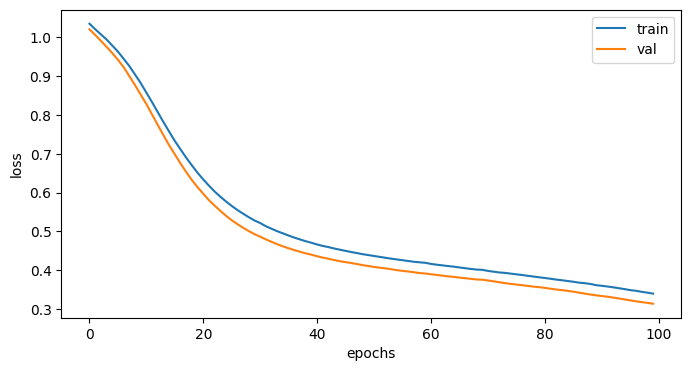

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.044139,0.530076,0.425785
18,True,False,False,0.998327,0.000080,0.001593
118,False,False,True,0.000059,0.124964,0.874977
78,False,True,False,0.021230,0.478521,0.500250
76,False,True,False,0.015996,0.456784,0.527220
31,True,False,False,0.996013,0.000317,0.003669
64,False,True,False,0.089013,0.564168,0.346818
141,False,False,True,0.000576,0.224718,0.774706
68,False,True,False,0.005049,0.367494,0.627457
82,False,True,False,0.071211,0.555908,0.372881


In [25]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

In [26]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [27]:
pd.DataFrame(pred)

,0,1,2
73,0.044139,0.530076,0.425785
18,0.998327,0.000080,0.001593
118,0.000059,0.124964,0.874977
78,0.021230,0.478521,0.500250
76,0.015996,0.456784,0.527220
31,0.996013,0.000317,0.003669
64,0.089013,0.564168,0.346818
141,0.000576,0.224718,0.774706
68,0.005049,0.367494,0.627457
82,0.071211,0.555908,0.372881


Functional API

In [28]:
from keras.models import Model

In [29]:
inputs = Input(shape=(mms_X_train.shape[1],))
x = Dense(16, activation='relu')(inputs)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - accuracy: 0.3628 - loss: 1.0566 - val_accuracy: 0.2667 - val_loss: 1.0469
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3993 - loss: 1.0424 - val_accuracy: 0.2667 - val_loss: 1.0360
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4198 - loss: 1.0327 - val_accuracy: 0.2333 - val_loss: 1.0255
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3596 - loss: 1.0359 - val_accuracy: 0.2667 - val_loss: 1.0147
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4026 - loss: 1.0124 - val_accuracy: 0.4000 - val_loss: 1.0038
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4552 - loss: 1.0053 - val_accuracy: 0.4667 - val_loss: 0.9925
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5979 - loss: 0.9873 - val_accuracy: 0.5000 - val_loss: 0.9809
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5963 - loss: 0.9823 - val_accuracy: 0.6333 - val_loss

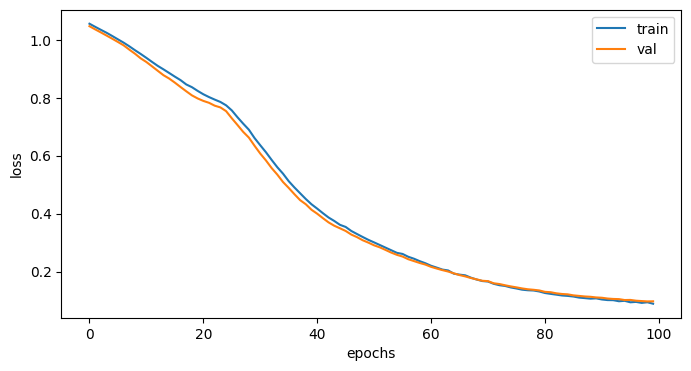

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,2.227370e-03,0.924678,0.073094
18,True,False,False,9.973937e-01,0.002573,0.000033
118,False,False,True,3.934156e-07,0.002684,0.997316
78,False,True,False,2.457820e-03,0.884427,0.113115
76,False,True,False,1.088302e-03,0.853714,0.145198
31,True,False,False,9.938400e-01,0.006067,0.000093
64,False,True,False,1.408414e-02,0.972280,0.013636
141,False,False,True,6.825780e-05,0.097920,0.902011
68,False,True,False,8.657329e-04,0.448741,0.550393
82,False,True,False,5.827542e-03,0.977633,0.016540


In [30]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

Subclass API

In [31]:
class Iris(Model):
    def __init__(self):
        super(Iris, self).__init__()
        self.dense1 =Dense(16, activation='relu')
        self.dense2 =Dense(8, activation='relu')
        self.dense3 =Dense(4, activation='relu')
        self.classifier = Dense(3, activation='softmax')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.classifier(x)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.4563 - loss: 1.0982 - val_accuracy: 0.7000 - val_loss: 1.0912
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6854 - loss: 1.0890 - val_accuracy: 0.7000 - val_loss: 1.0836
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6163 - loss: 1.0844 - val_accuracy: 0.7000 - val_loss: 1.0757
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6354 - loss: 1.0757 - val_accuracy: 0.7000 - val_loss: 1.0674
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6129 - loss: 1.0668 - val_accuracy: 0.7000 - val_loss: 1.0586
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6037 - loss: 1.0607 - val_accuracy: 0.7000 - val_loss: 1.0486
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6368 - loss: 1.0460 - val_accuracy: 0.7000 - val_loss: 1.0370
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6834 - loss: 1.0314 - val_accuracy: 0.7000 - val_loss

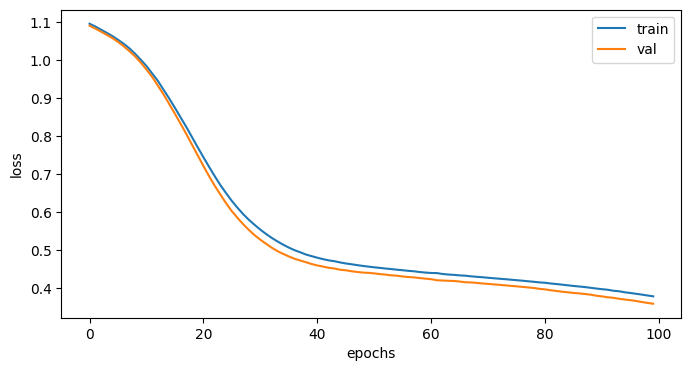

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.012037,0.465241,0.522722
18,True,False,False,0.999578,0.000138,0.000283
118,False,False,True,0.000060,0.200097,0.799843
78,False,True,False,0.011238,0.461389,0.527373
76,False,True,False,0.004784,0.412636,0.582580
31,True,False,False,0.998847,0.000424,0.000729
64,False,True,False,0.076230,0.538430,0.385340
141,False,False,True,0.000816,0.315757,0.683427
68,False,True,False,0.002733,0.380868,0.616399
82,False,True,False,0.035155,0.520153,0.444692


In [32]:
model2 = Iris()
model2.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model2.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model2.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result